In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf

import warnings
warnings.filterwarnings("ignore")


ERROR 1: PROJ: proj_create_from_database: Open of /nesi/project/niwa00018/queenle/ml_env_v2/share/proj failed


In [2]:
def fire_season(month):
    return (month >= 5) & (month <= 10)    
    
def get_linregress_slope(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = np.polyfit([i for i in range(len(arr))],arr,deg=1)[0]
        
    return(result)


In [3]:
ERA5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/FWI_6month_fire_season_ERA5_resolution.nc')
d4pdf = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')
cam5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')

vege_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/vegetation/1951-2021.nc')
vege_ds['longitude'] = [lon + 360 for lon in vege_ds.longitude.data]
era5_combined = (vege_ds.lai_hv + vege_ds.lai_lv).max('time')
era5_vege_mask = era5_combined.where(era5_combined>3.5)

vege_ds_coarsened = vege_ds.coarsen(latitude=3,longitude=3,boundary='pad').mean()

cam5_vege = vege_ds_coarsened.interp(longitude=cam5.longitude, latitude=cam5.latitude, method="linear")
cam5_combined = (cam5_vege.lai_hv + cam5_vege.lai_lv).max('time')
cam5_vege_mask = cam5_combined.where(cam5_combined>3.5)

d4pdf_vege = vege_ds_coarsened.interp(longitude=d4pdf.longitude, latitude=d4pdf.latitude, method="linear")
d4pdf_combined = (d4pdf_vege.lai_hv + d4pdf_vege.lai_lv).max('time')
d4pdf_vege_mask = d4pdf_combined.where(d4pdf_combined>3.5)

ERA5 = ERA5.reindex(latitude=list(reversed(ERA5.latitude)))
ERA5 = ERA5.where(era5_vege_mask>0)
d4pdf = d4pdf.where(d4pdf_vege_mask>0)
cam5 = cam5.where(cam5_vege_mask>0)

ERA5_anom = ERA5 - ERA5.mean('time')
d4pdf_anom = d4pdf - d4pdf.mean('time')
cam5_anom = cam5 - cam5.mean('time')


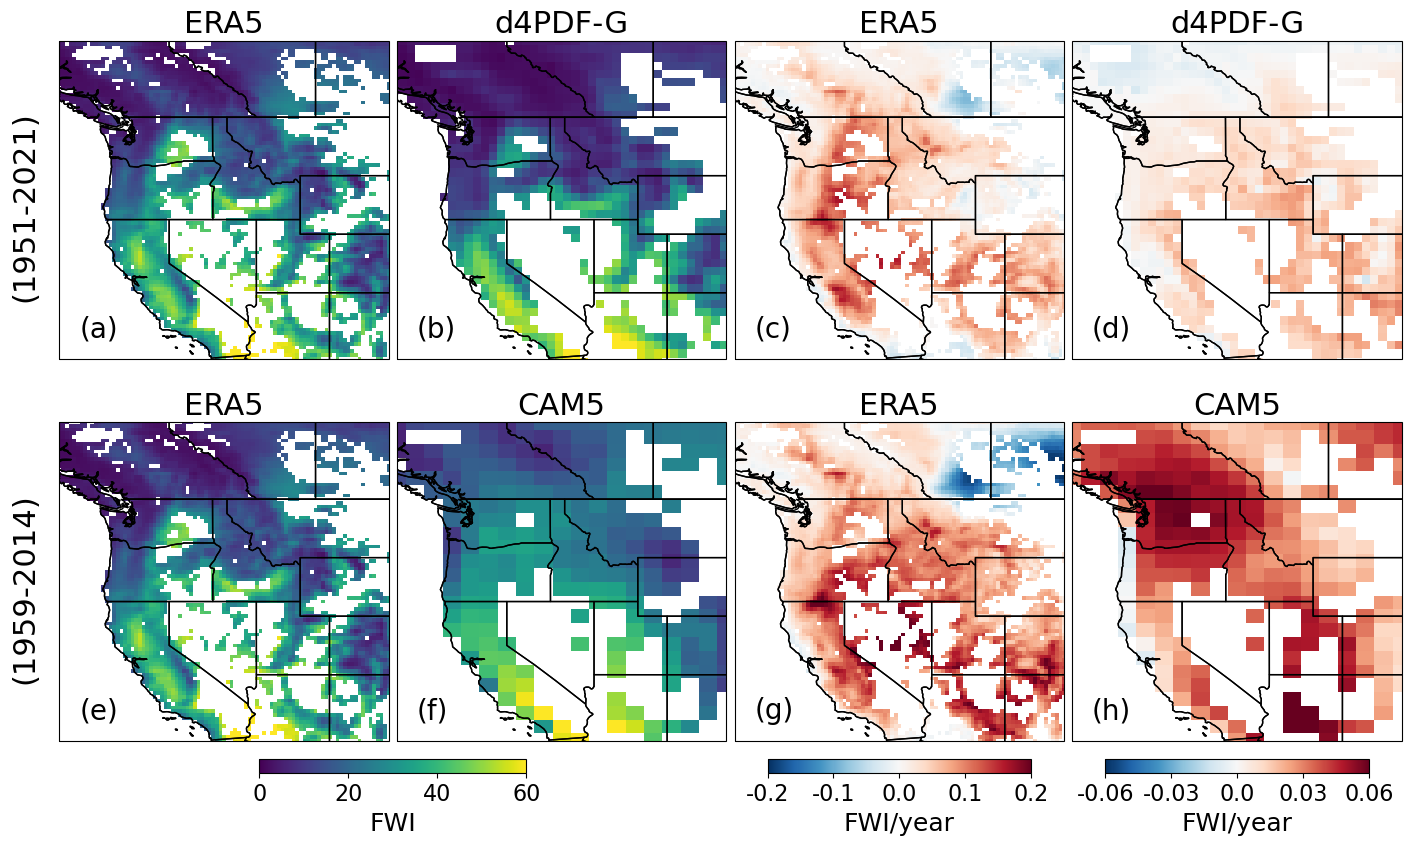

In [4]:

box = [(32,55),(232,256)]

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 20,
        }

labels = ['a','b','c','d','e','f','g','h']
count = 0
fig,axs = plt.subplots(2,4,figsize=(14,8.3), layout='constrained',subplot_kw=dict(projection=ccrs.PlateCarree()))

for i,model in enumerate(['d4pdf','cam5']):
    
    if model == 'd4pdf':
        model_da = d4pdf
        (start,end) = ('1951','2021')
    elif model == 'cam5':
        model_da = cam5
        (start,end) = ('1959','2014')
        
    for j,da in enumerate([ERA5,model_da]):

        da_subset = da.sel(time=slice(start,end))
        da_subset = da_subset.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        
        # mean
        mean_im = da_subset.mean('time').plot(ax=axs[i][j],vmin=0,vmax=60,transform=ccrs.PlateCarree(),add_colorbar=False)

        # trend
        if j == 0:
            era_trend_im = xr.apply_ufunc(get_linregress_slope, da_subset, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i][j+2],vmin=-0.2,vmax=0.2,cmap='RdBu_r',transform=ccrs.PlateCarree(),add_colorbar=False)
        elif j == 1:
            model_trend_im = xr.apply_ufunc(get_linregress_slope, da_subset, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i][j+2],vmin=-0.06,vmax=0.06,cmap='RdBu_r',transform=ccrs.PlateCarree(),add_colorbar=False)

        for k in [0,2]:
            axs[i][j+k].coastlines()
            axs[i][j+k].add_feature(cf.BORDERS)
            axs[i][j+k].add_feature(cf.STATES)
            axs[i][j+k].set_extent([232.5,255, 32.5,54.18])#, crs=noproj)
            axs[i][int(2*j+(k-0.5*k))].text(0.06,0.07,'('+labels[count]+')',transform=axs[i][int(2*j+(k-0.5*k))].transAxes,fontdict=font)
            count += 1

font['size']=16
cb = fig.colorbar(mean_im, ax=axs[1, 0:2], shrink=0.4,orientation='horizontal')
cb.set_ticks([20*i for i in range(4)],labels=[str(20*i) for i in range(4)],fontdict=font)
font['size']=18
cb.set_label('FWI',fontdict=font)

font['size']=16
cb = fig.colorbar(era_trend_im, ax=axs[1, 2], shrink=0.8,orientation='horizontal')
cb.set_ticks([-0.2, -0.1, 0.0, 0.1, 0.2],labels=[str(val) for val in [-0.2, -0.1, 0.0, 0.1, 0.2]],fontdict=font)
font['size']=18
cb.set_label('FWI/year',fontdict=font)

font['size']=16
cb = fig.colorbar(model_trend_im, ax=axs[1, 3], shrink=0.8,orientation='horizontal')
cb.set_ticks([-0.06, -0.03, 0.0, 0.03, 0.06],labels=[str(val) for val in [-0.06, -0.03, 0.0, 0.03, 0.06]],fontdict=font)
font['size']=18
cb.set_label('FWI/year',fontdict=font)

font['size']=22
axs[0][0].text(-0.15,0.2,'(1951-2021)',fontdict=font,transform=axs[0][0].transAxes, rotation='vertical',ma='center')
axs[1][0].text(-0.15,0.2,'(1959-2014)',fontdict=font,transform=axs[1][0].transAxes, rotation='vertical',ma='center')


plot_titles = ['ERA5','d4PDF-G','ERA5','d4PDF-G','ERA5','CAM5','ERA5','CAM5']
for i,ax in enumerate(axs.flatten()):
    ax.set_title(plot_titles[i],fontdict=font)
    

#plt.savefig('../figures/Figure1.png',dpi=300)

Text(-0.25, 0.2, 'ERA5 / cam5 \n(1959-2018)')

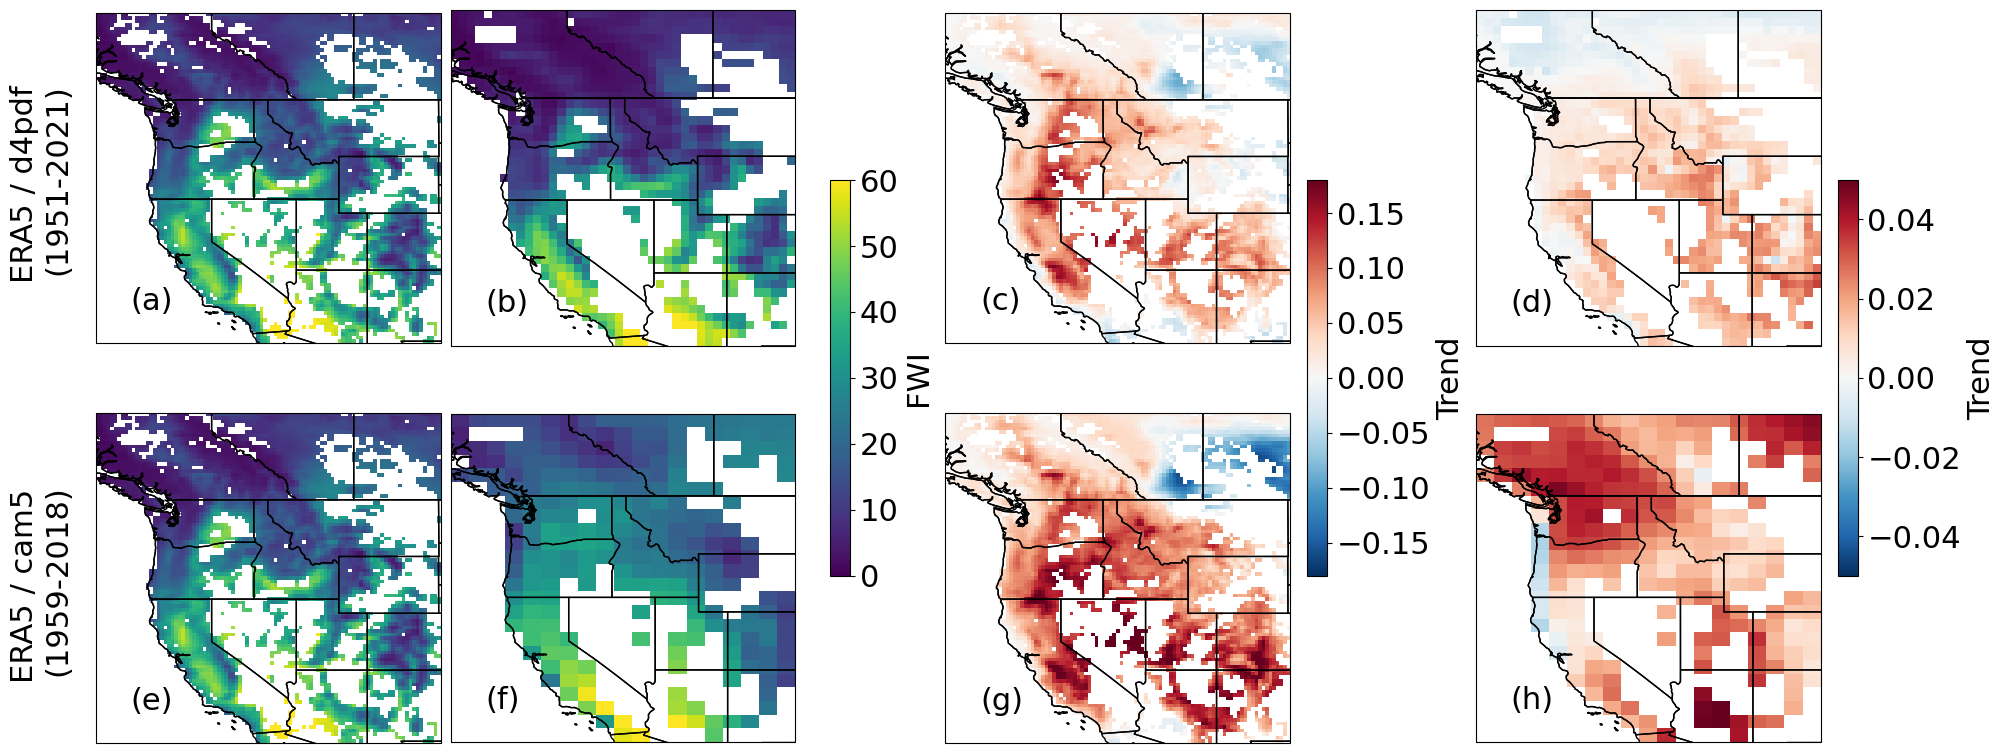

In [44]:
box = [(32,55),(232,256)]

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }

labels = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)']
count = 0
fig,axs = plt.subplots(2,4,figsize=(20,8), layout='constrained',subplot_kw=dict(projection=ccrs.PlateCarree()))

for i,model in enumerate(['d4pdf','cam5']):
    
    if model == 'd4pdf':
        model_da = d4pdf
        (start,end) = ('1951','2021')
    elif model == 'cam5':
        model_da = cam5
        (start,end) = ('1959','2018')
        
    for j,da in enumerate([ERA5,model_da]):

        da_subset = da.sel(time=slice(start,end))
        da_subset = da_subset.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        
        # mean
        mean_im = da_subset.mean('time').plot(ax=axs[i][j],vmin=0,vmax=60,transform=ccrs.PlateCarree(),add_colorbar=False)

        # trend
        if j == 0:
            era_trend_im = xr.apply_ufunc(get_linregress_slope, da_subset, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i][j+2],vmin=-0.18,vmax=0.18,cmap='RdBu_r',transform=ccrs.PlateCarree(),add_colorbar=False)
        elif j == 1:
            model_trend_im = xr.apply_ufunc(get_linregress_slope, da_subset, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i][j+2],vmin=-0.05,vmax=0.05,cmap='RdBu_r',transform=ccrs.PlateCarree(),add_colorbar=False)

        for k in [0,2]:
            axs[i][j+k].coastlines()
            axs[i][j+k].add_feature(cf.BORDERS)
            axs[i][j+k].add_feature(cf.STATES)
        
            axs[i][int(2*j+(k-0.5*k))].text(0.1,0.1,labels[count],transform=axs[i][int(2*j+(k-0.5*k))].transAxes,fontdict=font)
            count += 1

cb = fig.colorbar(mean_im, ax=axs[0:2, 0:2], shrink=0.5)
cb.set_label(label='FWI',fontdict=font)
cb.set_ticklabels(cb.ax.get_yticklabels(),fontdict=font,fontsize=7)

cb = fig.colorbar(era_trend_im, ax=axs[0:2, 2], shrink=0.5)
cb.set_label(label='Trend',fontdict=font)
cb.set_ticklabels(cb.ax.get_yticklabels(),fontdict=font,fontsize=14)

cb = fig.colorbar(model_trend_im, ax=axs[0:2, 3], shrink=0.5)
cb.set_label(label='Trend',fontdict=font)
cb.set_ticklabels(cb.ax.get_yticklabels(),fontdict=font,fontsize=14)

axs[0][0].text(-0.25,0.2,'ERA5 / d4pdf \n(1951-2021)',fontdict=font,transform=axs[0][0].transAxes, rotation='vertical',ma='center')
axs[1][0].text(-0.25,0.2,'ERA5 / cam5 \n(1959-2014)',fontdict=font,transform=axs[1][0].transAxes, rotation='vertical',ma='center')

#plt.savefig('../figures/Figure1.png',dpi=300)

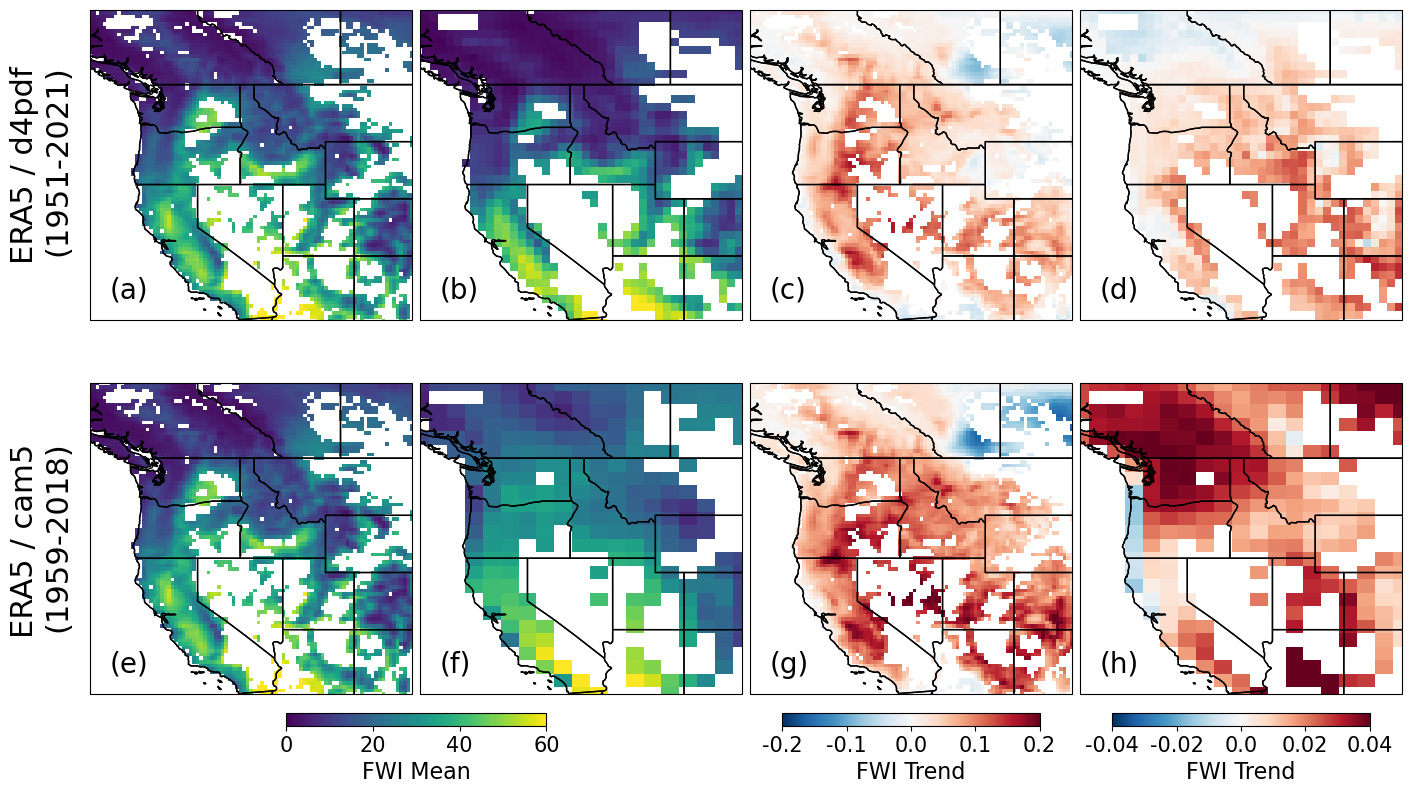

Text(0.2, 1.05, 'ERA5 / cam5 \n(1959-2018)')

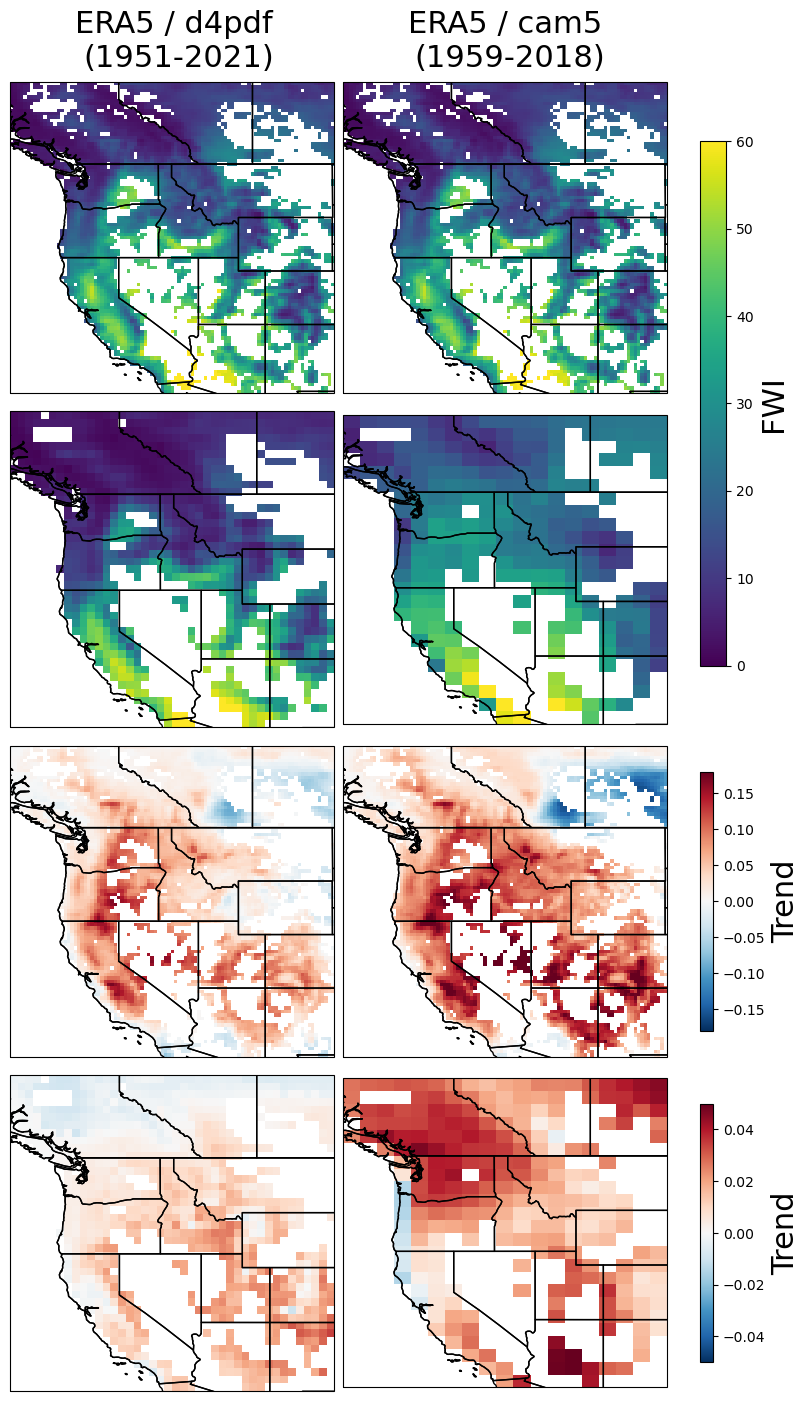

In [63]:
box = [(32,55),(232,256)]

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }

labels = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)']
count = 0
fig,axs = plt.subplots(4,2,figsize=(8,14), layout='constrained',subplot_kw=dict(projection=ccrs.PlateCarree()))

for j,model in enumerate(['d4pdf','cam5']):
    
    if model == 'd4pdf':
        model_da = d4pdf
        (start,end) = ('1951','2021')
    elif model == 'cam5':
        model_da = cam5
        (start,end) = ('1959','2018')
        
    for i,da in enumerate([ERA5,model_da]):

        da_subset = da.sel(time=slice(start,end))
        da_subset = da_subset.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        
        # mean
        mean_im = da_subset.mean('time').plot(ax=axs[i][j],vmin=0,vmax=60,transform=ccrs.PlateCarree(),add_colorbar=False)

        # trend
        if i == 0:
            era_trend_im = xr.apply_ufunc(get_linregress_slope, da_subset, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i+2][j],vmin=-0.18,vmax=0.18,cmap='RdBu_r',transform=ccrs.PlateCarree(),add_colorbar=False)
        elif i == 1:
            model_trend_im = xr.apply_ufunc(get_linregress_slope, da_subset, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i+2][j],vmin=-0.05,vmax=0.05,cmap='RdBu_r',transform=ccrs.PlateCarree(),add_colorbar=False)

        for k in [0,2]:
            axs[i+k][j].coastlines()
            axs[i+k][j].add_feature(cf.BORDERS)
            axs[i+k][j].add_feature(cf.STATES)
        
            #axs[i][int(2*j+(k-0.5*k))].text(0.1,0.1,labels[count],transform=axs[i][int(2*j+(k-0.5*k))].transAxes,fontdict=font)
            count += 1

cb = fig.colorbar(mean_im, ax=axs[0:2, 0:2], shrink=0.8,orientation='vertical')
cb.set_label(label='FWI',fontdict=font)
#cb.set_ticklabels(cb.ax.get_yticklabels(),fontdict=font,fontsize=7)

cb = fig.colorbar(era_trend_im, ax=axs[2, 0:2], shrink=0.8,orientation='vertical')
cb.set_label(label='Trend',fontdict=font)
#cb.set_ticklabels(cb.ax.get_yticklabels(),fontdict=font,fontsize=14)

cb = fig.colorbar(model_trend_im, ax=axs[3, 0:2], shrink=0.8,orientation='vertical')
cb.set_label(label='Trend',fontdict=font)
#cb.set_ticklabels(cb.ax.get_yticklabels(),fontdict=font,fontsize=14)

axs[0][0].text(0.2,1.05,'ERA5 / d4pdf \n(1951-2021)',fontdict=font,transform=axs[0][0].transAxes, rotation='horizontal',ma='center')
axs[0][1].text(0.2,1.05,'ERA5 / cam5 \n(1959-2018)',fontdict=font,transform=axs[0][1].transAxes, rotation='horizontal',ma='center')

#plt.savefig('../figures/Figure1.png',dpi=300)

Text(0.45, 0.47, 'Trend\nFWI')

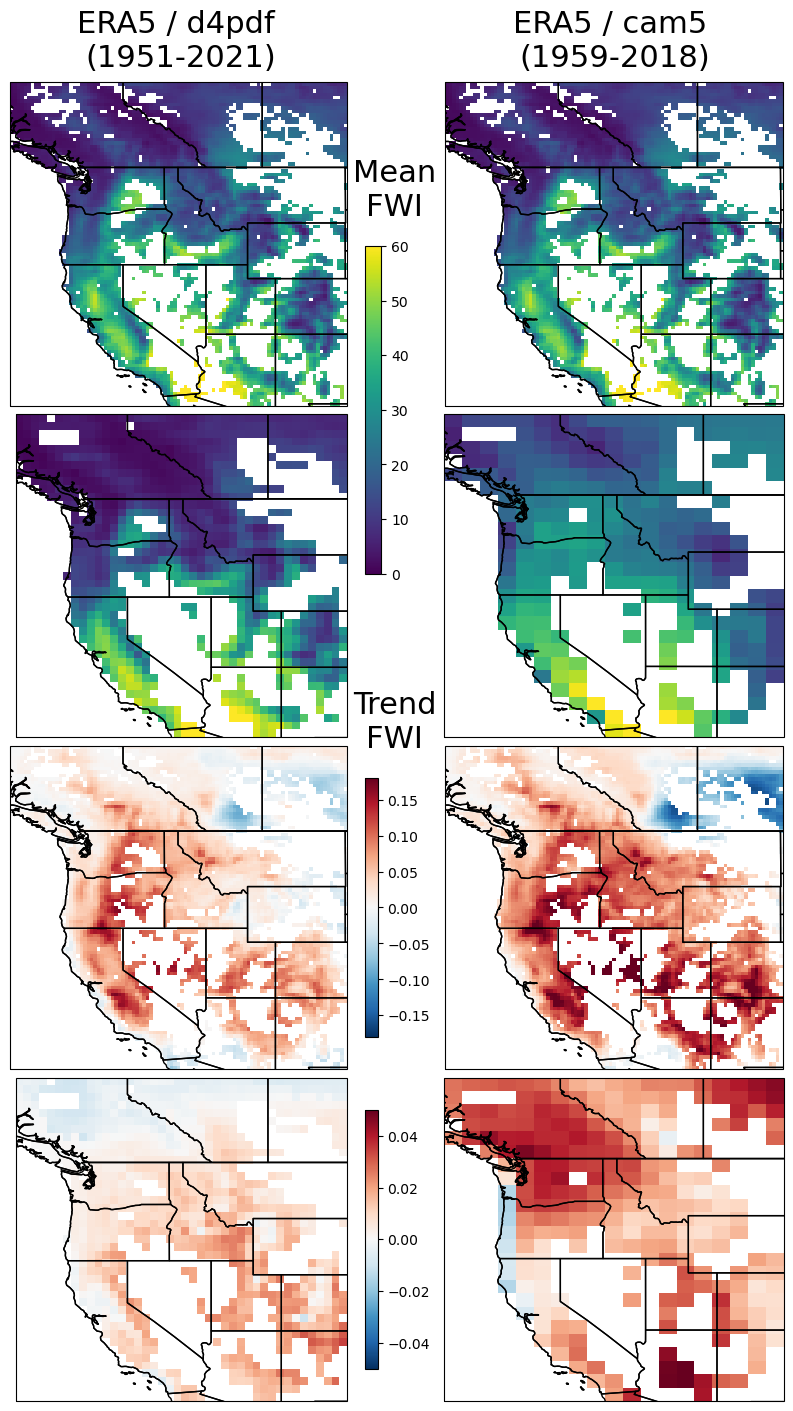

In [78]:
box = [(32,55),(232,256)]

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }

labels = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)']
count = 0
fig,axs = plt.subplots(4,2,figsize=(8,14), layout='constrained',subplot_kw=dict(projection=ccrs.PlateCarree()))

for j,model in enumerate(['d4pdf','cam5']):
    
    if model == 'd4pdf':
        model_da = d4pdf
        (start,end) = ('1951','2021')
    elif model == 'cam5':
        model_da = cam5
        (start,end) = ('1959','2018')
        
    for i,da in enumerate([ERA5,model_da]):

        da_subset = da.sel(time=slice(start,end))
        da_subset = da_subset.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        
        # mean
        mean_im = da_subset.mean('time').plot(ax=axs[i][j],vmin=0,vmax=60,transform=ccrs.PlateCarree(),add_colorbar=False)

        # trend
        if i == 0:
            era_trend_im = xr.apply_ufunc(get_linregress_slope, da_subset, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i+2][j],vmin=-0.18,vmax=0.18,cmap='RdBu_r',transform=ccrs.PlateCarree(),add_colorbar=False)
        elif i == 1:
            model_trend_im = xr.apply_ufunc(get_linregress_slope, da_subset, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i+2][j],vmin=-0.05,vmax=0.05,cmap='RdBu_r',transform=ccrs.PlateCarree(),add_colorbar=False)

        for k in [0,2]:
            axs[i+k][j].coastlines()
            axs[i+k][j].add_feature(cf.BORDERS)
            axs[i+k][j].add_feature(cf.STATES)
        
            #axs[i][int(2*j+(k-0.5*k))].text(0.1,0.1,labels[count],transform=axs[i][int(2*j+(k-0.5*k))].transAxes,fontdict=font)
            count += 1

cb = fig.colorbar(mean_im, ax=axs[0:2, 0], shrink=0.5,orientation='vertical')
#axs[0][0].text(1.1,0.9,'Mean\nFWI',fontdict=font,transform=axs[0][0].transAxes, rotation='horizontal',ma='center')
#axs[0][1].text(-0.1,0.9,'Mean\nFWI',fontdict=font,transform=axs[0][1].transAxes, rotation='horizontal',ma='center')
#cb.set_label(label='FWI',fontdict=font,loc='top')
#cb.set_ticklabels(cb.ax.get_yticklabels(),fontdict=font,fontsize=7)

cb = fig.colorbar(era_trend_im, ax=axs[2, 0], shrink=0.8,orientation='vertical')
#axs[2][0].text(1.1,0.9,'Trend',fontdict=font,transform=axs[2][0].transAxes, rotation='horizontal',ma='center')

#cb.set_label(label='Trend',fontdict=font,loc='top')
#cb.set_ticklabels(cb.ax.get_yticklabels(),fontdict=font,fontsize=14)

cb = fig.colorbar(model_trend_im, ax=axs[3, 0], shrink=0.8,orientation='vertical')
#cb.set_label(label='Trend',fontdict=font,loc='top')
#cb.set_ticklabels(cb.ax.get_yticklabels(),fontdict=font,fontsize=14)

axs[0][0].text(0.2,1.05,'ERA5 / d4pdf \n(1951-2021)',fontdict=font,transform=axs[0][0].transAxes, rotation='horizontal',ma='center')
axs[0][1].text(0.2,1.05,'ERA5 / cam5 \n(1959-2018)',fontdict=font,transform=axs[0][1].transAxes, rotation='horizontal',ma='center')

plt.figtext(0.45, 0.85, 'Mean\nFWI', fontdict=font,ma='center')
plt.figtext(0.45, 0.47, 'Trend\nFWI', fontdict=font,ma='center')

#plt.savefig('../figures/Figure1.png',dpi=300)

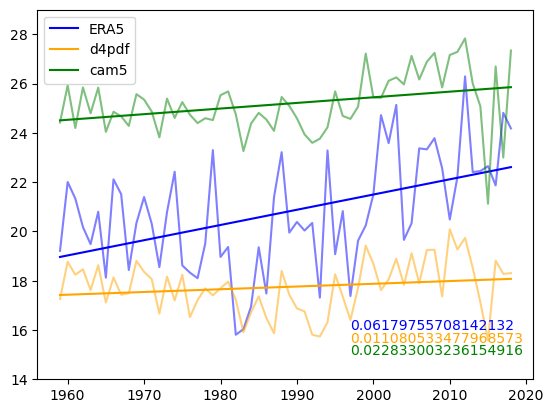

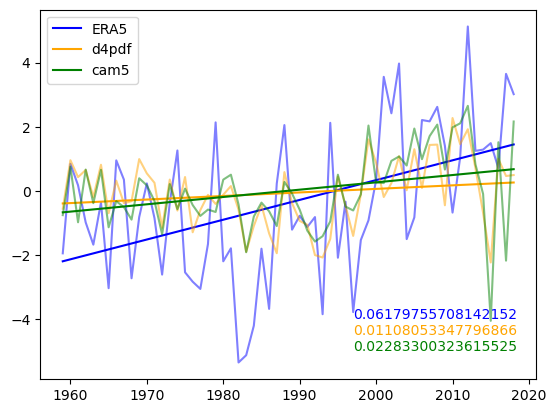

In [43]:
colors = ['blue','orange','green']
labels = ['ERA5','d4pdf','cam5']
for i,da in enumerate([ERA5,d4pdf,cam5]):
    da = da.sel(time=slice("1959","2018"))
    da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

    start_year = da.time.dt.year[0].data.tolist()
    
    ts = da.mean(['latitude','longitude']).data.flatten()
    plt.plot([i+start_year for i in range(len(ts))],ts,alpha=0.5,color=colors[i])
    m,b = np.polyfit([i for i in range(len(ts))],ts,deg=1)
    plt.plot([i+start_year for i in range(len(ts))],[m*i + b for i in range(len(ts))],color=colors[i],label=labels[i])
    plt.text(1997,16-0.5*i,str(m),color=colors[i])

plt.legend()
plt.ylim(14,29)
plt.show()
plt.close()

for i,da in enumerate([ERA5_anom,d4pdf_anom,cam5_anom]):
    
    da = da.sel(time=slice("1959","2018"))
    da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
    
    start_year = da.time.dt.year[0].data.tolist()

    ts = da.mean(['latitude','longitude']).data.flatten()
    plt.plot([i+start_year for i in range(len(ts))],ts,alpha=0.5,color=colors[i])
    m,b = np.polyfit([i for i in range(len(ts))],ts,deg=1)
    plt.plot([i+start_year for i in range(len(ts))],[m*i + b for i in range(len(ts))],color=colors[i],label=labels[i])
    plt.text(1997,-4-0.5*i,str(m),color=colors[i])

plt.legend()
plt.show()
plt.close()

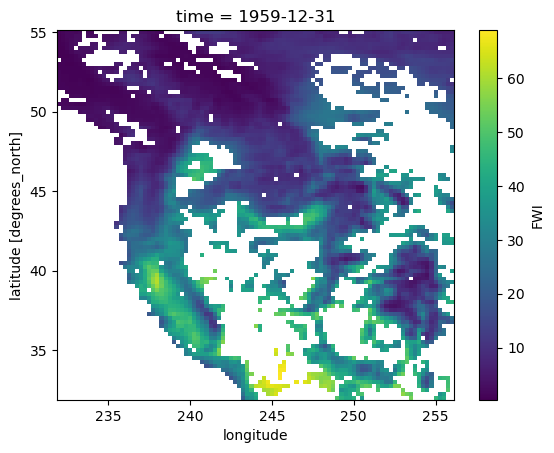

In [7]:
da = ERA5

da = da.sel(time=slice("1959","2018"))
da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        
da.isel(time=0).plot()


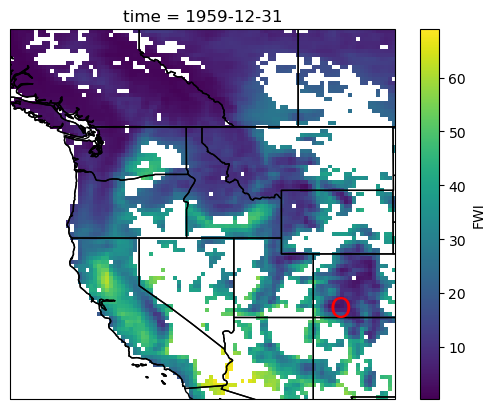

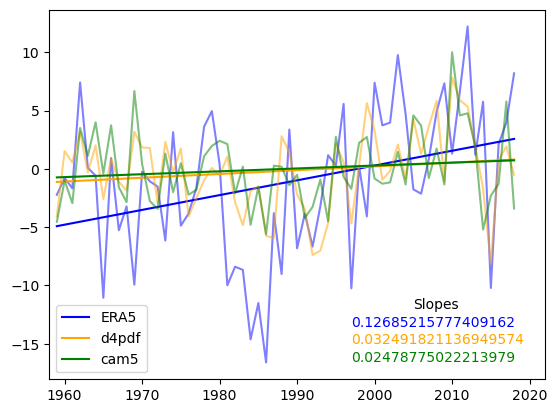

In [44]:
(lat,lon) = (37,252)

fig,axs = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))
da = ERA5

da = da.sel(time=slice("1959","2018"))
da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        
da.isel(time=0).plot(ax=axs,transform=ccrs.PlateCarree())
axs.text(lon,lat,'O',c='red',fontsize=20,transform=ccrs.PlateCarree())

axs.coastlines()  # cartopy function
axs.add_feature(cf.BORDERS)
axs.add_feature(cf.STATES)
        
plt.show()
plt.close()

plt.text(2005,-12,'Slopes')

ERA5_anom_ts = ERA5_anom.sel(time=slice("1959","2018")).sel(latitude=lat,longitude=lon,method='nearest').data
plt.plot([i+1959 for i in range(len(ERA5_anom_ts))],ERA5_anom_ts,alpha=0.5,color='blue')
m,b = np.polyfit([i for i in range(len(ERA5_anom_ts))],ERA5_anom_ts,deg=1)
plt.plot([i+1959 for i in range(len(ERA5_anom_ts))],[m*i + b for i in range(len(ERA5_anom_ts))],color='blue',label='ERA5')
plt.text(1997,-13.5,str(m),color='blue')

d4pdf_anom_ts = d4pdf_anom.sel(time=slice("1959","2018")).sel(latitude=lat,longitude=lon,method='nearest').data.flatten()
plt.plot([i+1959 for i in range(len(d4pdf_anom_ts))],d4pdf_anom_ts,alpha=0.5,color='orange')
m,b = np.polyfit([i for i in range(len(d4pdf_anom_ts))],d4pdf_anom_ts,deg=1)
plt.plot([i+1959 for i in range(len(d4pdf_anom_ts))],[m*i + b for i in range(len(d4pdf_anom_ts))],color='orange',label='d4pdf')
plt.text(1997,-15,str(m),color='orange')

cam5_anom_ts = cam5_anom.sel(time=slice("1959","2018")).sel(latitude=lat,longitude=lon,method='nearest').data.flatten()
plt.plot([i+1959 for i in range(len(cam5_anom_ts))],cam5_anom_ts,alpha=0.5,color='green')
m,b = np.polyfit([i for i in range(len(cam5_anom_ts))],cam5_anom_ts,deg=1)
plt.plot([i+1959 for i in range(len(cam5_anom_ts))],[m*i + b for i in range(len(cam5_anom_ts))],color='green',label='cam5')
plt.text(1997,-16.5,str(m),color='green')

plt.xlim(1958,2022)
plt.legend()

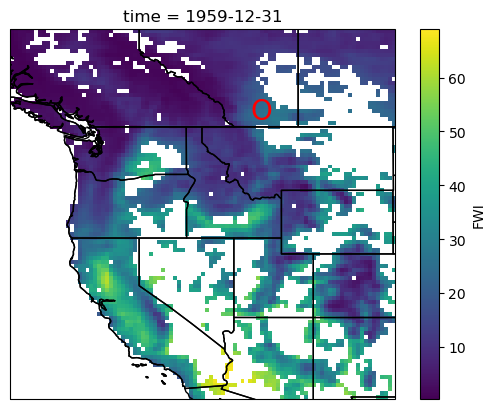

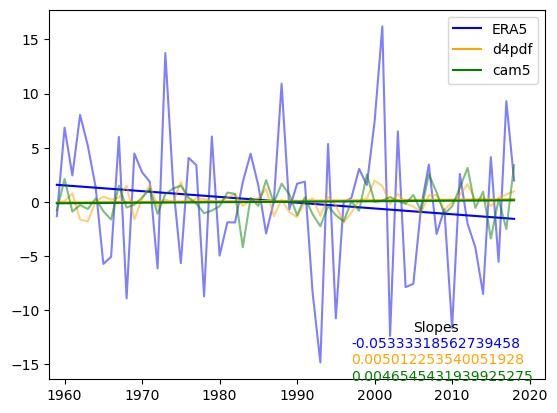

In [45]:
(lat,lon) = (49.5,247)

fig,axs = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))
da = ERA5

da = da.sel(time=slice("1959","2018"))
da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        
da.isel(time=0).plot(ax=axs,transform=ccrs.PlateCarree())
axs.text(lon,lat,'O',c='red',fontsize=20,transform=ccrs.PlateCarree())

axs.coastlines()  # cartopy function
axs.add_feature(cf.BORDERS)
axs.add_feature(cf.STATES)
        
plt.show()
plt.close()

plt.text(2005,-12,'Slopes')

ERA5_anom_ts = ERA5_anom.sel(time=slice("1959","2018")).sel(latitude=lat,longitude=lon,method='nearest').data
plt.plot([i+1959 for i in range(len(ERA5_anom_ts))],ERA5_anom_ts,alpha=0.5,color='blue')
m,b = np.polyfit([i for i in range(len(ERA5_anom_ts))],ERA5_anom_ts,deg=1)
plt.plot([i+1959 for i in range(len(ERA5_anom_ts))],[m*i + b for i in range(len(ERA5_anom_ts))],color='blue',label='ERA5')
plt.text(1997,-13.5,str(m),color='blue')

d4pdf_anom_ts = d4pdf_anom.sel(time=slice("1959","2018")).sel(latitude=lat,longitude=lon,method='nearest').data.flatten()
plt.plot([i+1959 for i in range(len(d4pdf_anom_ts))],d4pdf_anom_ts,alpha=0.5,color='orange')
m,b = np.polyfit([i for i in range(len(d4pdf_anom_ts))],d4pdf_anom_ts,deg=1)
plt.plot([i+1959 for i in range(len(d4pdf_anom_ts))],[m*i + b for i in range(len(d4pdf_anom_ts))],color='orange',label='d4pdf')
plt.text(1997,-15,str(m),color='orange')

cam5_anom_ts = cam5_anom.sel(time=slice("1959","2018")).sel(latitude=lat,longitude=lon,method='nearest').data.flatten()
plt.plot([i+1959 for i in range(len(cam5_anom_ts))],cam5_anom_ts,alpha=0.5,color='green')
m,b = np.polyfit([i for i in range(len(cam5_anom_ts))],cam5_anom_ts,deg=1)
plt.plot([i+1959 for i in range(len(cam5_anom_ts))],[m*i + b for i in range(len(cam5_anom_ts))],color='green',label='cam5')
plt.text(1997,-16.5,str(m),color='green')

plt.xlim(1958,2022)
plt.legend()

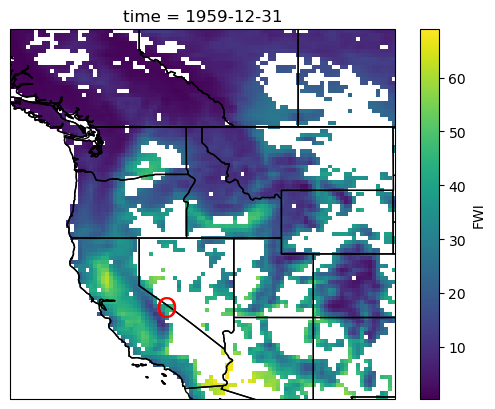

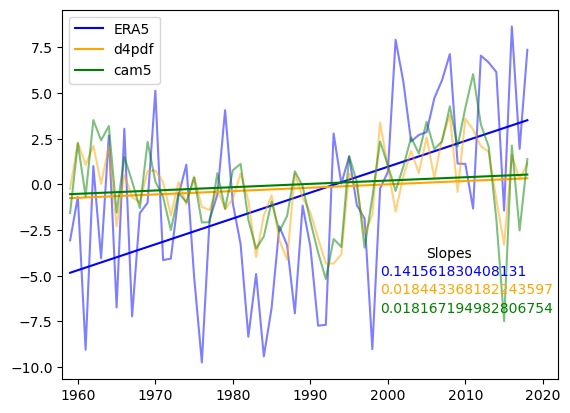

In [49]:
(lat,lon) = (37,241)

fig,axs = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))
da = ERA5

da = da.sel(time=slice("1959","2018"))
da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        
da.isel(time=0).plot(ax=axs,transform=ccrs.PlateCarree())
axs.text(lon,lat,'O',c='red',fontsize=20,transform=ccrs.PlateCarree())

axs.coastlines()  # cartopy function
axs.add_feature(cf.BORDERS)
axs.add_feature(cf.STATES)
        
plt.show()
plt.close()

plt.text(2005,-4,'Slopes')

ERA5_anom_ts = ERA5_anom.sel(time=slice("1959","2018")).sel(latitude=lat,longitude=lon,method='nearest').data
plt.plot([i+1959 for i in range(len(ERA5_anom_ts))],ERA5_anom_ts,alpha=0.5,color='blue')
m,b = np.polyfit([i for i in range(len(ERA5_anom_ts))],ERA5_anom_ts,deg=1)
plt.plot([i+1959 for i in range(len(ERA5_anom_ts))],[m*i + b for i in range(len(ERA5_anom_ts))],color='blue',label='ERA5')
plt.text(1999,-5,str(m),color='blue')

d4pdf_anom_ts = d4pdf_anom.sel(time=slice("1959","2018")).sel(latitude=lat,longitude=lon,method='nearest').data.flatten()
plt.plot([i+1959 for i in range(len(d4pdf_anom_ts))],d4pdf_anom_ts,alpha=0.5,color='orange')
m,b = np.polyfit([i for i in range(len(d4pdf_anom_ts))],d4pdf_anom_ts,deg=1)
plt.plot([i+1959 for i in range(len(d4pdf_anom_ts))],[m*i + b for i in range(len(d4pdf_anom_ts))],color='orange',label='d4pdf')
plt.text(1999,-6,str(m),color='orange')

cam5_anom_ts = cam5_anom.sel(time=slice("1959","2018")).sel(latitude=lat,longitude=lon,method='nearest').data.flatten()
plt.plot([i+1959 for i in range(len(cam5_anom_ts))],cam5_anom_ts,alpha=0.5,color='green')
m,b = np.polyfit([i for i in range(len(cam5_anom_ts))],cam5_anom_ts,deg=1)
plt.plot([i+1959 for i in range(len(cam5_anom_ts))],[m*i + b for i in range(len(cam5_anom_ts))],color='green',label='cam5')
plt.text(1999,-7,str(m),color='green')

plt.xlim(1958,2022)
plt.legend()

In [12]:
cam5_anom_ts.flatten()

array([-4.54644076, -1.00006709, -2.94440666,  3.50975273,  1.11549772,
        3.99552193, -0.4116476 ,  3.73329831, -1.57821939, -2.85514667,
        6.67870617,  0.42186355, -2.76799113, -3.43356801,  1.31052781,
       -2.00034313,  0.4797697 , -2.21389097, -1.80035703,  1.07794351,
        1.96356309,  2.40976603,  2.12588134, -2.10457441,  0.19289668,
       -4.79088557, -1.55554299, -5.59928513,  0.27762481,  0.17838336,
       -1.39840079, -0.51316175, -4.2036442 , -3.258382  , -0.91777956,
       -4.48359121,  2.75428723, -0.69022321, -1.7097286 ,  2.23139526,
        2.7327943 , -0.83313287, -1.27394031, -1.15992002,  1.45278844,
       -1.33824013,  4.59354987,  3.7124842 , -0.78595155,  1.74483101,
       -1.33477784, 10.00746541,  4.57965904,  4.7715585 ,  1.86207382,
       -5.20297727, -2.29847738, -1.29069137,  5.77851872, -3.39701593])

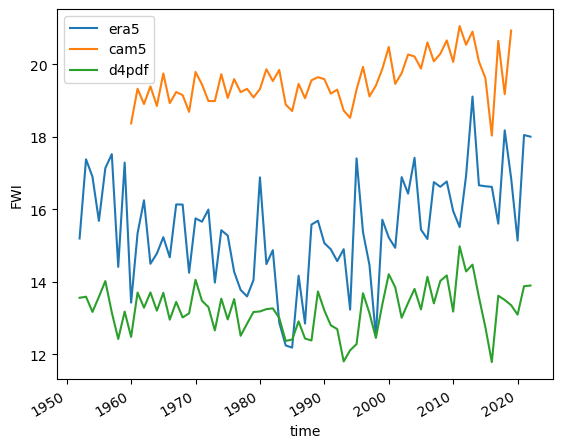

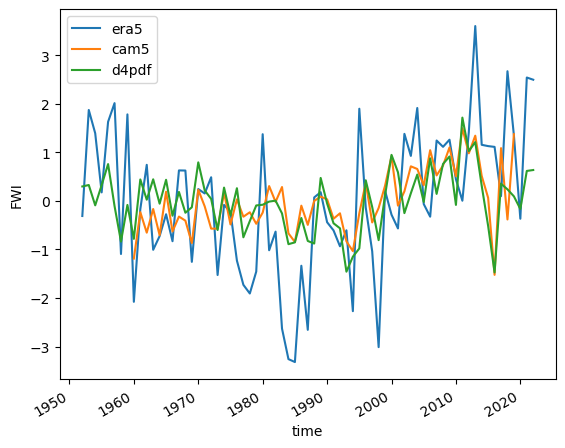

In [7]:
ERA5.mean(['latitude','longitude']).plot(label='era5')
cam5.mean(['latitude','longitude']).plot(label='cam5')
d4pdf.mean(['latitude','longitude']).plot(label='d4pdf')
plt.legend()
plt.show()
plt.close()

ERA5_anom.mean(['latitude','longitude']).plot(label='era5')
cam5_anom.mean(['latitude','longitude']).plot(label='cam5')
d4pdf_anom.mean(['latitude','longitude']).plot(label='d4pdf')
plt.legend()
plt.show()
plt.close()